In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from my_nn import activations, loss, metrics, nn
from my_nn.data.sample_data import generate_data, plot_data

In [2]:
# first get the data
data, targets = generate_data(seed=42)

#### For this notebook we will be looking at multiclass classification using the target defined by a hyperbolic boundary.

In [3]:
# set up X, y for training
# use numpy arrays here for now so train test split works properly
X = np.array(data[["x1","x2"]])
y = np.array(data["multiclass"])
data_used = data[["x1","x2","multiclass"]].copy()

In [4]:
# do a train_test split
X_train, X_test, y_train, y_test = nn.train_test_split(X, y, test_size = 0.2, random_state=42)

In [5]:
# create 3 versions of the model to train. These will be identical here, and will only differ in how the .fit() is called
model_sgd = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 3, activation="softmax")
)

model_momentum = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 3, activation="softmax")
)

model_adam = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 3, activation="softmax")
)

In [6]:
# train the models
history_sgd = model_sgd.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="categorical_cross_entropy",
    metric="accuracy",
    val_size = 0.2,
    optimizer="sgd"
)

Epoch 1 complete. Average Loss: 0.8248 , accuracy 0.6353 -  Validation Loss: 0.7544, Validation accuracy 0.6138
Epoch 2 complete. Average Loss: 0.6993 , accuracy 0.7256 -  Validation Loss: 0.6608, Validation accuracy 0.7131
Epoch 3 complete. Average Loss: 0.6219 , accuracy 0.7338 -  Validation Loss: 0.5896, Validation accuracy 0.7219
Epoch 4 complete. Average Loss: 0.5623 , accuracy 0.8059 -  Validation Loss: 0.5338, Validation accuracy 0.7981
Epoch 5 complete. Average Loss: 0.5144 , accuracy 0.8461 -  Validation Loss: 0.4886, Validation accuracy 0.8506
Epoch 6 complete. Average Loss: 0.4758 , accuracy 0.8545 -  Validation Loss: 0.4516, Validation accuracy 0.8638
Epoch 7 complete. Average Loss: 0.4437 , accuracy 0.8619 -  Validation Loss: 0.4211, Validation accuracy 0.8762
Epoch 8 complete. Average Loss: 0.4171 , accuracy 0.8634 -  Validation Loss: 0.3953, Validation accuracy 0.8806
Epoch 9 complete. Average Loss: 0.3944 , accuracy 0.8688 -  Validation Loss: 0.3737, Validation accuracy

In [9]:
history_momentum = model_momentum.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="categorical_cross_entropy",
    metric="accuracy",
    val_size = 0.2,
    optimizer="momentum"
)

Epoch 1 complete. Average Loss: 0.8817 , accuracy 0.7366 -  Validation Loss: 0.7370, Validation accuracy 0.7400
Epoch 2 complete. Average Loss: 0.6756 , accuracy 0.7711 -  Validation Loss: 0.6023, Validation accuracy 0.7750
Epoch 3 complete. Average Loss: 0.5679 , accuracy 0.8495 -  Validation Loss: 0.5157, Validation accuracy 0.8581
Epoch 4 complete. Average Loss: 0.4938 , accuracy 0.8698 -  Validation Loss: 0.4539, Validation accuracy 0.8712
Epoch 5 complete. Average Loss: 0.4394 , accuracy 0.8806 -  Validation Loss: 0.4076, Validation accuracy 0.8862
Epoch 6 complete. Average Loss: 0.3981 , accuracy 0.8878 -  Validation Loss: 0.3720, Validation accuracy 0.8925
Epoch 7 complete. Average Loss: 0.3663 , accuracy 0.8934 -  Validation Loss: 0.3449, Validation accuracy 0.8981
Epoch 8 complete. Average Loss: 0.3417 , accuracy 0.8941 -  Validation Loss: 0.3232, Validation accuracy 0.8981
Epoch 9 complete. Average Loss: 0.3221 , accuracy 0.8975 -  Validation Loss: 0.3060, Validation accuracy

In [10]:
history_adam = model_adam.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="categorical_cross_entropy",
    metric="accuracy",
    val_size = 0.2,
    optimizer="adam"
)

Epoch 1 complete. Average Loss: 0.1855 , accuracy 0.9477 -  Validation Loss: 0.1864, Validation accuracy 0.9419
Epoch 2 complete. Average Loss: 0.0800 , accuracy 0.9187 -  Validation Loss: 0.2333, Validation accuracy 0.9163
Epoch 3 complete. Average Loss: 0.0732 , accuracy 0.9794 -  Validation Loss: 0.0524, Validation accuracy 0.9788
Epoch 4 complete. Average Loss: 0.0570 , accuracy 0.9783 -  Validation Loss: 0.0402, Validation accuracy 0.9838
Epoch 5 complete. Average Loss: 0.0672 , accuracy 0.9875 -  Validation Loss: 0.0328, Validation accuracy 0.9862
Epoch 6 complete. Average Loss: 0.0619 , accuracy 0.9547 -  Validation Loss: 0.0935, Validation accuracy 0.9663
Epoch 7 complete. Average Loss: 0.0581 , accuracy 0.9641 -  Validation Loss: 0.0819, Validation accuracy 0.9637
Epoch 8 complete. Average Loss: 0.0668 , accuracy 0.9550 -  Validation Loss: 0.1102, Validation accuracy 0.9531
Epoch 9 complete. Average Loss: 0.0577 , accuracy 0.9669 -  Validation Loss: 0.1366, Validation accuracy

#### Let's look at the histories of each

##### First, for standard gradient descent

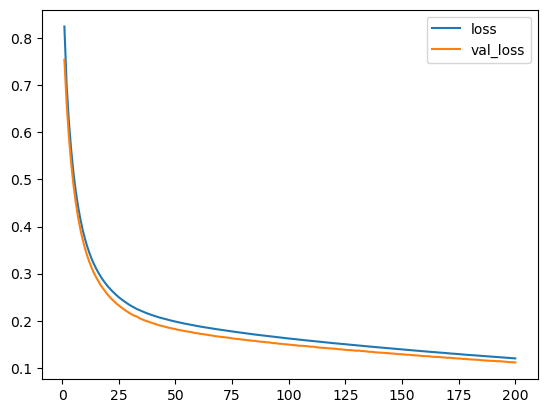

In [11]:
nn.plot_history(history_sgd, "loss", "val_loss")

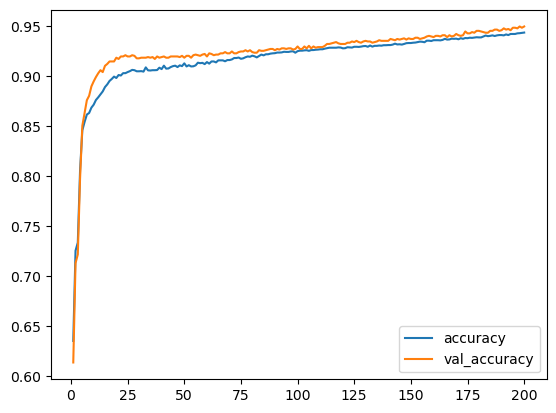

In [12]:
nn.plot_history(history_sgd, "accuracy", "val_accuracy")

##### Next, for using momentum

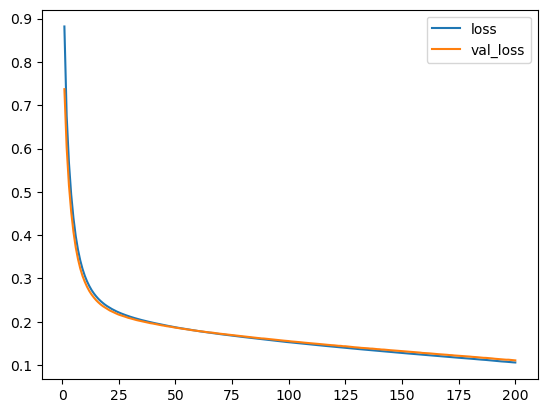

In [13]:
nn.plot_history(history_momentum, "loss", "val_loss")

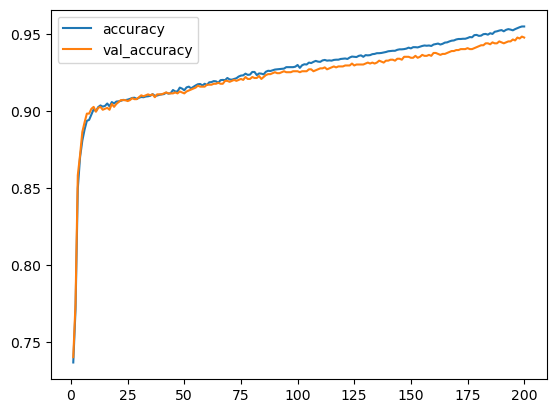

In [14]:
nn.plot_history(history_momentum, "accuracy", "val_accuracy")

##### Finally for adam optimization

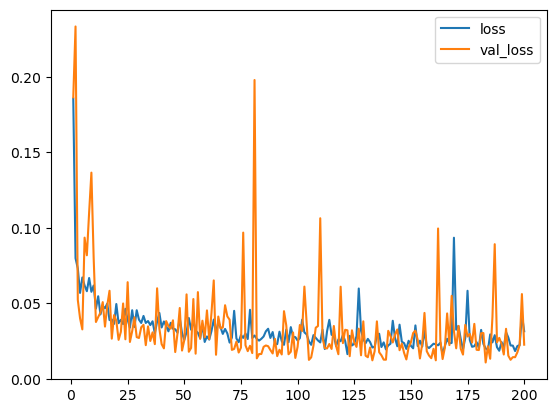

In [15]:
nn.plot_history(history_adam, "loss", "val_loss")

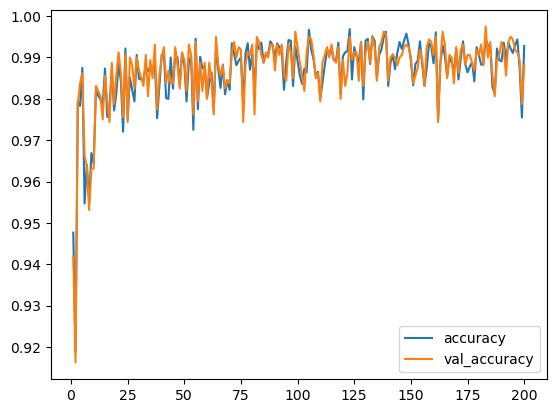

In [16]:
nn.plot_history(history_adam, "accuracy", "val_accuracy")

#### Now let's see how they do on unseen test data

In [17]:
y_pred_sgd = model_sgd.predict(X_test)
y_pred_momentum = model_momentum.predict(X_test)
y_pred_adam = model_adam.predict(X_test)

In [18]:
print("SGD all real numbers: ", np.isfinite(y_pred_sgd).all())
print("Momentum all real numbers: ",np.isfinite(y_pred_momentum).all())
print("Adam all real numbers: ", np.isfinite(y_pred_adam).all())

SGD all real numbers:  True
Momentum all real numbers:  True
Adam all real numbers:  True


In [19]:
# Convert to labels to use to measure accuracy
y_pred_sgd_labels = np.argmax(y_pred_sgd, axis=1)
y_pred_mom_labels = np.argmax(y_pred_momentum, axis=1)
y_pred_adam_labels = np.argmax(y_pred_adam, axis=1)

In [20]:
acc_sgd = metrics.accuracy(y_test, y_pred_sgd_labels)
acc_mom = metrics.accuracy(y_test, y_pred_mom_labels)
acc_adam = metrics.accuracy(y_test, y_pred_adam_labels)

In [21]:
# since we only have one metric currently for multiclass we can just print in one cell
print(f"Accuracy for SGD : {acc_sgd : .4f}")
print(f"Accuracy for momentum : {acc_mom: .4f}")
print(f"Accuracy for adam optimization : {acc_adam: .4f}")

Accuracy for SGD :  0.9525
Accuracy for momentum :  0.9555
Accuracy for adam optimization :  0.9935


#### Lastly we look at visualizing how the model does on the whole space for each version. All will show the true decision boundary and scatterplot the points, coloring by prediction.

In [22]:
y_pred_sgd = np.argmax(model_sgd.predict(X), axis=1)
y_pred_mom = np.argmax(model_momentum.predict(X), axis=1)
y_pred_adam = np.argmax(model_adam.predict(X), axis=1)

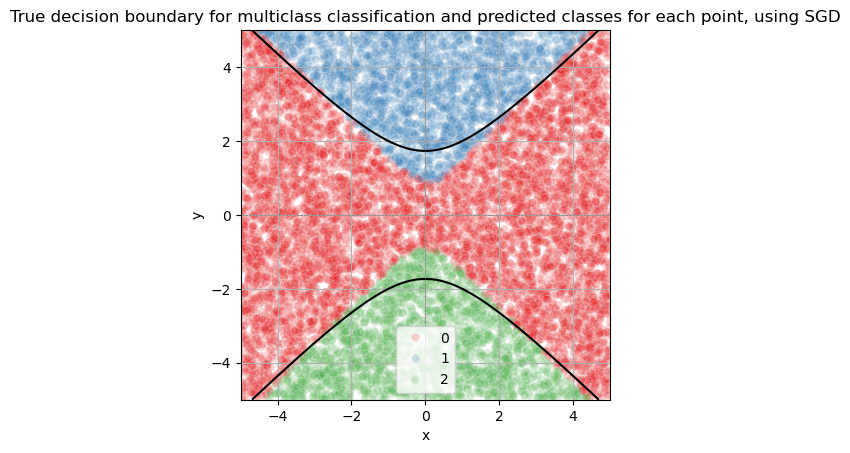

In [23]:
# Create a grid of x and y values
x = np.linspace(-5, 5, 400)
y = np.linspace(-5, 5, 400)
X_vals, Y_vals = np.meshgrid(x, y)

# Define the hyperbola equation
F = Y_vals**2- X_vals**2 

# Plot the hyperbola using contour
plt.contour(X_vals, Y_vals, F, [3], colors='k', linestyles='solid')
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_pred_sgd.ravel(), palette='Set1', alpha=0.2)

# Add labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title("True decision boundary for multiclass classification and predicted classes for each point, using SGD")
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box') # Ensure proper aspect ratio
plt.show()

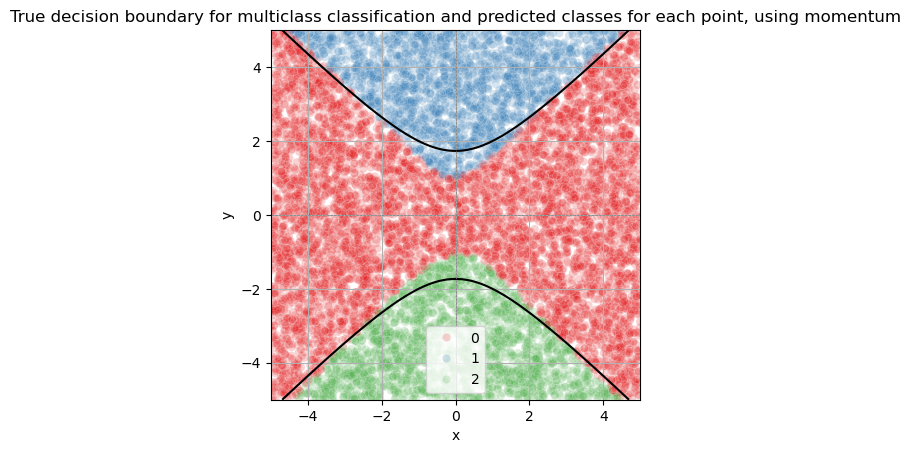

In [24]:
# Create a grid of x and y values
x = np.linspace(-5, 5, 400)
y = np.linspace(-5, 5, 400)
X_vals, Y_vals = np.meshgrid(x, y)

# Define the hyperbola equation
F = Y_vals**2- X_vals**2 

# Plot the hyperbola using contour
plt.contour(X_vals, Y_vals, F, [3], colors='k', linestyles='solid')
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_pred_mom.ravel(), palette='Set1', alpha=0.2)

# Add labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title("True decision boundary for multiclass classification and predicted classes for each point, using momentum")
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box') # Ensure proper aspect ratio
plt.show()

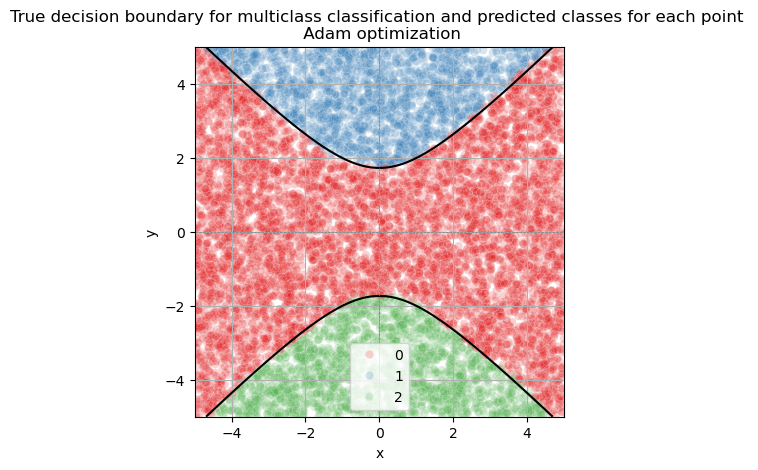

In [25]:
# Create a grid of x and y values
x = np.linspace(-5, 5, 400)
y = np.linspace(-5, 5, 400)
X_vals, Y_vals = np.meshgrid(x, y)

# Define the hyperbola equation
F = Y_vals**2- X_vals**2 

# Plot the hyperbola using contour
plt.contour(X_vals, Y_vals, F, [3], colors='k', linestyles='solid')
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_pred_adam.ravel(), palette='Set1', alpha=0.2)

# Add labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title("True decision boundary for multiclass classification and predicted classes for each point \n Adam optimization")
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box') # Ensure proper aspect ratio
plt.show()